# Notebook 04 — System validation against the HSECoE AX-21 reference (Gate V3)

This notebook reproduces the Gate V3 comparison on a **full-state** basis: the two
metrics compared to the published anchor are `GC_full = m_h2_full / m_sys` (kg H2 per kg
system) and `VC_full = m_h2_full / V_sys` (kg H2 per litre of system), i.e. the numerator
is the full-state hydrogen inventory rather than the usable swing.

All physics lives in the `h2star` package, per the architecture rule: this notebook only
loads data, calls package functions, forms the two ratios from the returned budget, prints
them, and draws the figure. No model equation is defined or reimplemented here.

The anchor values and the ±tolerance are **pre-registered** in `docs/validation_plan.md`
and are loaded at runtime from `data/validation/hsecoe_reference.yaml`; no anchor number is
written into this notebook.

Gate V3 is a **documented FAIL**, localized to the engineering-mass block, and is recorded
as a strict xfail in `tests/test_system_validation.py`. See GitHub issue #1.

The call sequence below mirrors `tests/test_system_validation.py` exactly, so the notebook
and the test compute `GC_full` / `VC_full` identically.

In [1]:
%matplotlib inline

from pathlib import Path

import yaml

from h2star import isotherm, system
from h2star.viz import plot_system_validation

## Load the pre-registered anchor

The anchor (HSECoE AX-21 activated carbon, Tamburello et al., SRNL, project ID ST044, 2013),
its full operating state, and the pre-registered tolerance are read from
`data/validation/hsecoe_reference.yaml` — the single source of truth for all four numbers.

In [2]:
# Paths are written relative to the repository root: this notebook is meant to be
# executed with the repo root as the working directory (e.g. by nbconvert). The
# fallback below also lets it run interactively from inside notebooks/.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path("..").resolve()

MATERIAL_YAML = REPO_ROOT / "data" / "materials" / "ax21.yaml"
ENGINEERING_YAML = REPO_ROOT / "data" / "engineering.yaml"
ANCHOR_YAML = REPO_ROOT / "data" / "validation" / "hsecoe_reference.yaml"

with open(ANCHOR_YAML) as fh:
    anchor = yaml.safe_load(fh)

full_state = anchor["operating_full_state"]
temperature_K = full_state["temperature_K"]
pressure_bar = full_state["pressure_bar"]

results = anchor["reference_results"]
gc_anchor = results["system_gravimetric_capacity_kg_per_kg"]["value"]
vc_anchor = results["system_volumetric_capacity_kg_per_L"]["value"]
tolerance_pct = anchor["tolerance_pct"]

print("citation      :", anchor["citation"])
print("basis         :", anchor["basis"])
print("full state    :", temperature_K, "K,", pressure_bar, "bar")
print("GC anchor     :", gc_anchor, results["system_gravimetric_capacity_kg_per_kg"]["unit"])
print("VC anchor     :", vc_anchor, results["system_volumetric_capacity_kg_per_L"]["unit"])
print("tolerance     : +/-", tolerance_pct, "%")

citation      : Tamburello, D. et al. (SRNL) — SRNL Technical Work Scope for the HSECoE: Design and Testing of Adsorbent Storage Systems. DOE Hydrogen and Fuel Cells Program 2013 Annual Merit Review, Project ID ST044, 2013.
basis         : full_state_system_inventory
full state    : 80 K, 200 bar
GC anchor     : 0.0312 kg_H2_per_kg_system
VC anchor     : 0.0194 kg_H2_per_L_system
tolerance     : +/- 15 %


## Build and size the AX-21 system

The full state is taken from the anchor (80 K / 200 bar as loaded above, converted from bar
to Pa); the empty state (5 bar, 160 K) is the sizing-only baseline that fixes the swing, and
the tank is sized to the 5.6 kg usable target (`system.size_for_usable` default).

In [3]:
material = isotherm.Material.from_yaml(MATERIAL_YAML)
da = isotherm.ModifiedDA(material)
engineering = system.EngineeringParams.from_yaml(ENGINEERING_YAML)

# SystemDesign takes its arguments POSITIONALLY:
# (material, isotherm, engineering, P_full, T_full, P_empty, T_empty)
design = system.SystemDesign(
    material,
    da,
    engineering,
    pressure_bar * 1.0e5,  # P_full, Pa (anchor pins the state in bar)
    temperature_K,         # T_full, K
    5.0e5,                 # P_empty, Pa (sizing-only baseline)
    160.0,                 # T_empty, K (sizing-only baseline)
)

V_internal = system.size_for_usable(design)  # m^3, 5.6 kg usable target
budget = design.evaluate(V_internal)

print(f"V_internal    = {V_internal:.6g} m^3")
print()
for key in (
    "m_h2_full",
    "m_usable",
    "m_sorbent",
    "m_vessel",
    "m_insulation",
    "m_bop",
    "m_sys",
):
    print(f"{key:<13} = {budget[key]:.6g} kg")
print()
for key in ("V_internal", "V_shell", "V_insulation", "V_sys"):
    print(f"{key:<13} = {budget[key]:.6g} m^3")

V_internal    = 0.116089 m^3

m_h2_full     = 5.8817 kg
m_usable      = 5.6 kg
m_sorbent     = 34.8266 kg
m_vessel      = 16.6846 kg
m_insulation  = 2.33293 kg
m_bop         = 16 kg
m_sys         = 75.7259 kg

V_internal    = 0.116089 m^3
V_shell       = 0.00656611 m^3
V_insulation  = 0.0393411 m^3
V_sys         = 0.161996 m^3


## Full-state system capacities

`GC_full` and `VC_full` take **`m_h2_full`** — the full-state hydrogen inventory — as the
numerator. They are therefore *not* `budget["GC"]` and `budget["VC"]`, which are swing-based
(numerator `m_usable`) and are deliberately not the Gate V3 metrics.

In [4]:
gc_full = budget["m_h2_full"] / budget["m_sys"]                # kg/kg
vc_full = budget["m_h2_full"] / (budget["V_sys"] * 1000.0)      # kg/L (m^3 -> L)

print(f"GC_full = {gc_full:.6g} kg/kg")
print(f"VC_full = {vc_full:.6g} kg/L")
print()

for label, model_value, anchor_value, unit in (
    ("GC", gc_full, gc_anchor, "kg/kg"),
    ("VC", vc_full, vc_anchor, "kg/L"),
):
    band = anchor_value * tolerance_pct / 100.0
    lo = anchor_value - band
    hi = anchor_value + band
    inside = abs(model_value - anchor_value) <= band
    print(
        f"{label}_full = {model_value:.6g} {unit} | "
        f"anchor {anchor_value:.6g} {unit} | "
        f"+/-{tolerance_pct:g}% band [{lo:.6g}, {hi:.6g}] {unit} | "
        f"{'INSIDE' if inside else 'OUTSIDE'} band"
    )

GC_full = 0.077671 kg/kg
VC_full = 0.0363077 kg/L

GC_full = 0.077671 kg/kg | anchor 0.0312 kg/kg | +/-15% band [0.02652, 0.03588] kg/kg | OUTSIDE band
VC_full = 0.0363077 kg/L | anchor 0.0194 kg/L | +/-15% band [0.01649, 0.02231] kg/L | OUTSIDE band


## Figure F4 — system validation

The tolerance band is drawn around the **anchor**, so model points falling outside it depict
the documented FAIL of Gate V3.

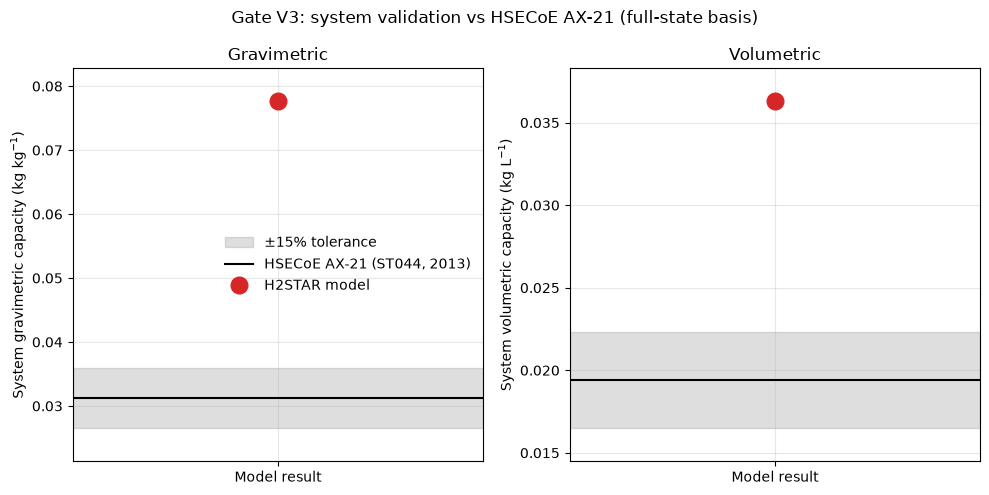

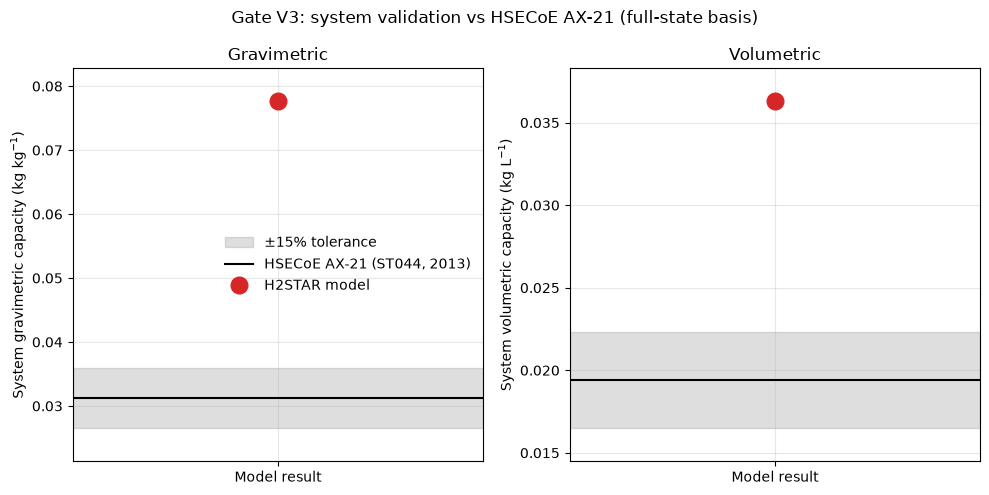

In [5]:
fig, (ax_gc, ax_vc) = plot_system_validation(
    gc_full,
    vc_full,
    gc_anchor,
    vc_anchor,
    tolerance_pct,
    savepath=REPO_ROOT / "figures" / "F4_system_validation.png",
)

fig

The interpretation of this result and its limitations are written up by the author in
`docs/` (validation plan and Gate V3 record); this notebook only reproduces the numbers and
the figure.